In [1]:
import yfinance as yf
import pandas as pd

# Visa Inc. (V)

## Collecting data

In [2]:
# Ticker
ticker = "V"

# Create a Ticker object
v = yf.Ticker(ticker)

In [3]:
'''Date:  from 2015-01-15 to 2015-09-07'''
'''Interval: daily data'''
data_v = v.history(start="2015-01-15", end="2015-09-07", interval="1d")

## Descriptive statistics

In [4]:
print(data_v.head())

                                Open       High        Low      Close  \
Date                                                                    
2015-01-15 00:00:00-05:00  59.295299  59.470847  58.290531  58.468388   
2015-01-16 00:00:00-05:00  58.184269  58.923413  58.091878  58.888763   
2015-01-20 00:00:00-05:00  59.182118  59.983624  58.729392  59.325325   
2015-01-21 00:00:00-05:00  59.168243  59.969749  58.784812  59.426941   
2015-01-22 00:00:00-05:00  59.004234  59.824220  58.523792  59.500847   

                             Volume  Dividends  Stock Splits  
Date                                                          
2015-01-15 00:00:00-05:00  10569200        0.0           0.0  
2015-01-16 00:00:00-05:00  11137200        0.0           0.0  
2015-01-20 00:00:00-05:00  14933200        0.0           0.0  
2015-01-21 00:00:00-05:00   9784000        0.0           0.0  
2015-01-22 00:00:00-05:00  11566000        0.0           0.0  


### Extract only the opening and closing price columns

In [5]:
# Extract only the opening and closing price columns
open_prices = data_v["Open"]
close_prices = data_v["Close"]

v_open_close = pd.DataFrame({"Date": open_prices.index, "Open": open_prices.values, "Close": close_prices.values})
v_open_close.reset_index(drop=True, inplace=True)
print(v_open_close.head())

                       Date       Open      Close
0 2015-01-15 00:00:00-05:00  59.295299  58.468388
1 2015-01-16 00:00:00-05:00  58.184269  58.888763
2 2015-01-20 00:00:00-05:00  59.182118  59.325325
3 2015-01-21 00:00:00-05:00  59.168243  59.426941
4 2015-01-22 00:00:00-05:00  59.004234  59.500847


### Extract only the closing price columns

In [6]:
# Extract only the closing price column
close_prices = data_v["Close"]

v_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
v_close.reset_index(drop=True, inplace=True)

print(v_close.head())

                       Date      Close
0 2015-01-15 00:00:00-05:00  58.468388
1 2015-01-16 00:00:00-05:00  58.888763
2 2015-01-20 00:00:00-05:00  59.325325
3 2015-01-21 00:00:00-05:00  59.426941
4 2015-01-22 00:00:00-05:00  59.500847


In [7]:
data_v.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,162.000000,162.000000,162.000000,162.000000,1.620000e+02,162.000000,162.000000
mean,63.495520,63.994138,62.889350,63.442419,8.832307e+06,0.002222,0.024691
std,2.936434,2.922386,2.928782,2.909957,5.041361e+06,0.016228,0.314270
min,57.174878,57.468226,55.724711,56.904621,3.473500e+06,0.000000,0.000000
25%,61.615146,61.988955,60.876039,61.376911,6.170975e+06,0.000000,0.000000
50%,63.204657,63.510452,62.657283,63.173756,7.296950e+06,0.000000,0.000000
75%,64.486421,64.959409,64.045806,64.560389,1.050035e+07,0.000000,0.000000
max,71.192402,71.322213,69.838652,70.821503,5.065800e+07,0.120000,4.000000


In [8]:
data_v.shape

(162, 7)

In [9]:
data_v.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 162 entries, 2015-01-15 00:00:00-05:00 to 2015-09-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          162 non-null    float64
 1   High          162 non-null    float64
 2   Low           162 non-null    float64
 3   Close         162 non-null    float64
 4   Volume        162 non-null    int64  
 5   Dividends     162 non-null    float64
 6   Stock Splits  162 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 10.1 KB


In [10]:
data_v.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

## KPIs

### Completeness

In [11]:
missing_values_count = data_v.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [12]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(data_v)

missing_info = pd.DataFrame({
    'missing_count': data_v.isnull().sum(),
    'missing_percentage': (data_v.isnull().sum() / total_rows) * 100
})

print(missing_info)

              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


### Latency

In [13]:
'''2.1 minimum and Maxmimum Close Price'''
min_close = data_v['Close'].min()
max_close = data_v['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 56.90462112426758
Maximum Close Price: 70.82150268554688
Difference between Max and Min Close Price: 13.916881561279297


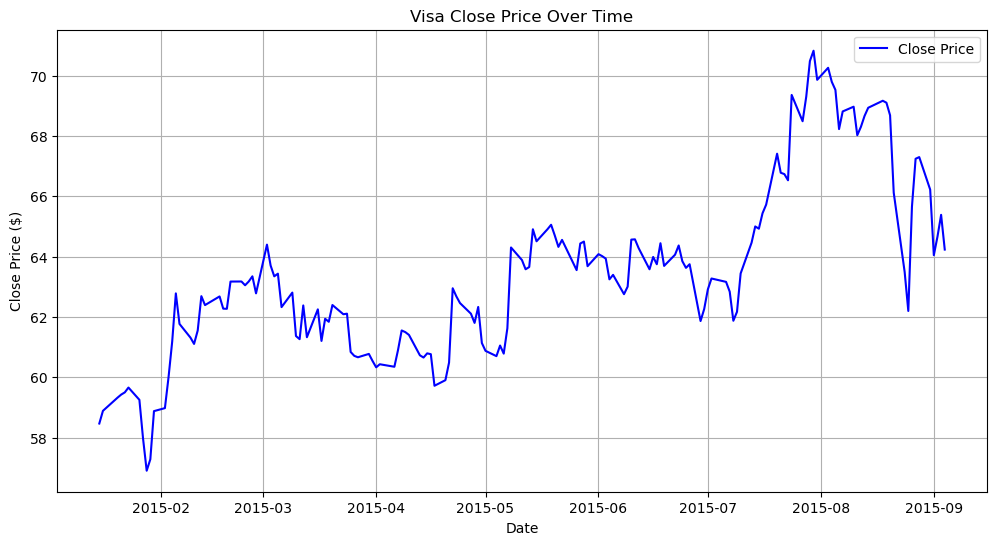

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
v_close['Date'] = pd.to_datetime(v_close['Date'])


# Set 'Date' as the index 
v_close.set_index('Date', inplace=True)


# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(v_close.index, v_close['Close'], color='blue', label='Close Price')
plt.title('Visa Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### Consistency

In [16]:
print(data_v.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [17]:
print(data_v.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


### Error rate

In [18]:
# Missing rate
missing_rate = data_v.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [19]:
# Duplicate rate
duplicate_rate = data_v.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [20]:
# Outliers
Q1 = data_v['Close'].quantile(0.25)
Q3 = data_v['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data_v['Close'] < Q1 - 1.5 * IQR) | (data_v['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

4.320987654320987


## ACCURACY

In [21]:
valid_close = data_v['Close'] > 0
valid_volume = data_v['Volume'] > 0
valid_dividends = data_v['Dividends'] >= 0

accurate_records = data_v[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data_v)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [22]:
invalid_records = data_v[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data_v)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")

❌ Invalid Value Rate: 0.00%


In [23]:
duplicate_rows = data_v.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data_v)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [24]:
unit_price_accuracy = (data_v['Close'] > 0).sum() / len(data_v) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
